# Makemore Part 3: 활성화, 기울기, BatchNorm

> 📺 Andrej Karpathy - "Building makemore Part 3"
> 🔗 https://www.youtube.com/watch?v=P6sfmUTpUmc

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 데이터 준비 (Part 2와 동일)

In [3]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
print(f'Train: {Xtr.shape}, Val: {Xdev.shape}')

Train: torch.Size([182625, 3]), Val: torch.Size([22655, 3])


---
## 📺 00:00 - 15:00 | 활성화 포화 문제 진단

tanh의 출력이 ±1에 몰리면 기울기가 0 → 학습 불가

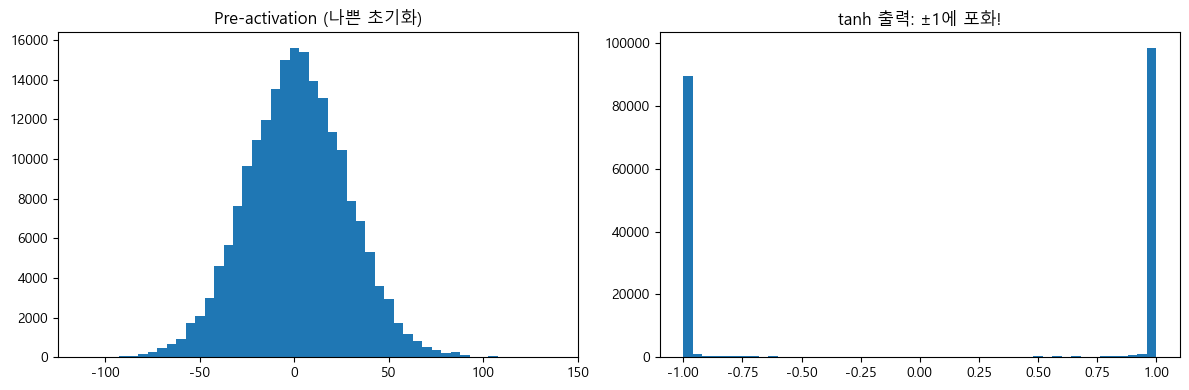

포화된 뉴런 비율: 91.79%


In [4]:
# 나쁜 초기화: 가중치가 너무 큼
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
W1_bad = torch.randn((block_size * n_embd, n_hidden), generator=g) * 5  # 너무 큰 가중치!
b1 = torch.randn(n_hidden, generator=g) * 0.01

# 순전파로 활성화 확인
emb = C[Xtr[:1000]]
embcat = emb.view(-1, block_size * n_embd)
h_preact_bad = embcat @ W1_bad + b1
h_bad = torch.tanh(h_preact_bad)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(h_preact_bad.view(-1).data, bins=50)
plt.title('Pre-activation (나쁜 초기화)')
plt.subplot(1, 2, 2)
plt.hist(h_bad.view(-1).data, bins=50)
plt.title('tanh 출력: ±1에 포화!')
plt.tight_layout()
plt.show()

print(f'포화된 뉴런 비율: {(h_bad.abs() > 0.99).float().mean():.2%}')

---
## 📺 15:00 - 30:00 | Kaiming 초기화

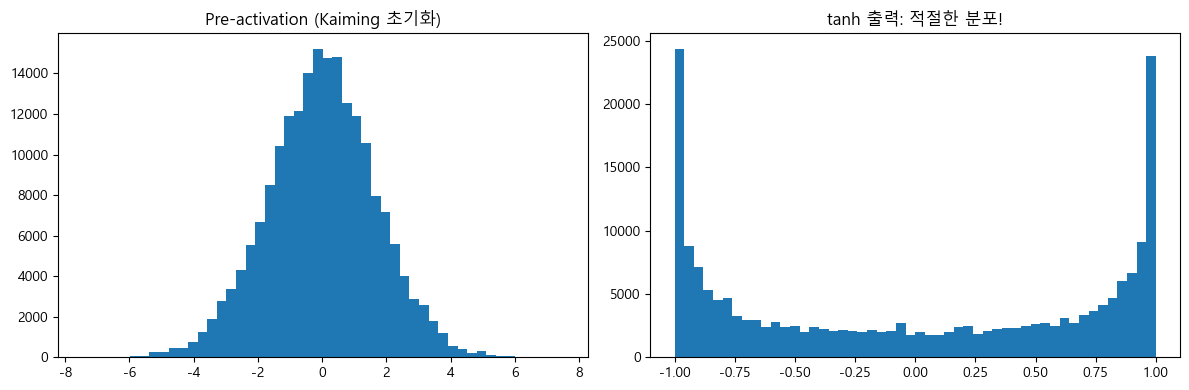

포화된 뉴런 비율: 11.51%


In [5]:
# 좋은 초기화: Kaiming
gain = 5/3  # tanh의 gain
W1_good = torch.randn((block_size * n_embd, n_hidden), generator=g) * gain / (block_size * n_embd)**0.5

h_preact_good = embcat @ W1_good + b1
h_good = torch.tanh(h_preact_good)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(h_preact_good.view(-1).data, bins=50)
plt.title('Pre-activation (Kaiming 초기화)')
plt.subplot(1, 2, 2)
plt.hist(h_good.view(-1).data, bins=50)
plt.title('tanh 출력: 적절한 분포!')
plt.tight_layout()
plt.show()

print(f'포화된 뉴런 비율: {(h_good.abs() > 0.99).float().mean():.2%}')

---
## 📺 30:00 - 01:05:00 | BatchNorm 적용 MLP

In [6]:
# BatchNorm 포함 MLP
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3) / (block_size * n_embd)**0.5
# BatchNorm 파라미터
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, bngain, bnbias, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f'총 파라미터 수: {sum(p.nelement() for p in parameters)}')

총 파라미터 수: 12097


In [7]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # 순전파 + BatchNorm
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1

    # BatchNorm: 정규화 → scale & shift
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias

    # running stats 업데이트
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    lossi.append(loss.log10().item())
    if i % 5000 == 0:
        print(f'Step {i:>5}: loss = {loss.item():.4f}')

Step     0: loss = 3.3239
Step  5000: loss = 2.0971
Step 10000: loss = 2.0322
Step 15000: loss = 2.6475
Step 20000: loss = 2.5675
Step 25000: loss = 2.3016


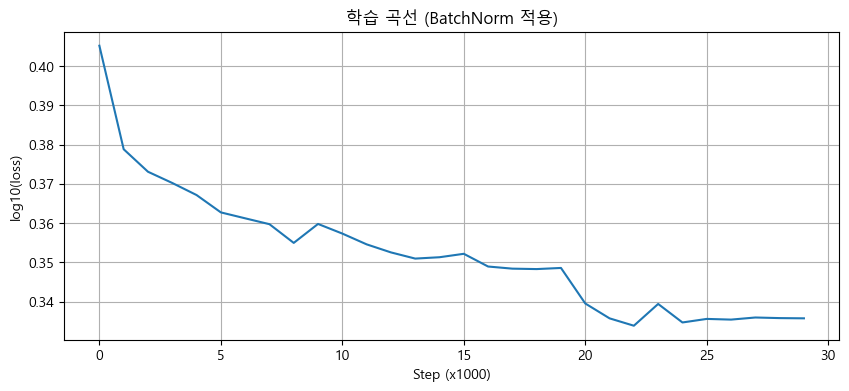

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.xlabel('Step (x1000)'); plt.ylabel('log10(loss)')
plt.title('학습 곡선 (BatchNorm 적용)')
plt.grid(True)
plt.show()

---
## 📺 01:05:00 - 01:20:00 | 활성화/기울기 분포 시각화

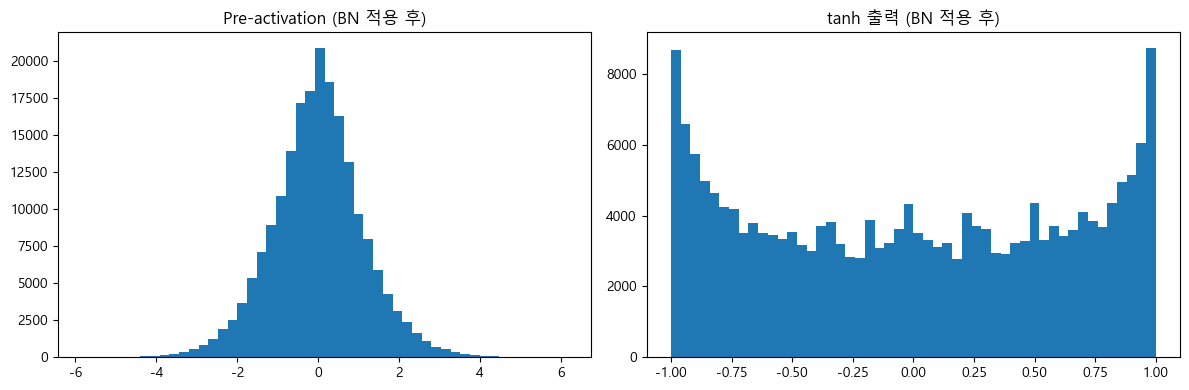

포화된 뉴런 비율: 2.69%


In [9]:
# 학습 후 활성화 분포 확인
with torch.no_grad():
    emb = C[Xtr[:1000]]
    embcat = emb.view(-1, block_size * n_embd)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / (bnstd_running + 1e-5) + bnbias
    h = torch.tanh(hpreact)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(hpreact.view(-1).data, bins=50)
plt.title('Pre-activation (BN 적용 후)')
plt.subplot(1, 2, 2)
plt.hist(h.view(-1).data, bins=50)
plt.title('tanh 출력 (BN 적용 후)')
plt.tight_layout()
plt.show()

print(f'포화된 뉴런 비율: {(h.abs() > 0.99).float().mean():.2%}')

---
## 평가

In [10]:
@torch.no_grad()
def eval_loss(X, Y):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / (bnstd_running + 1e-5) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

print(f'Train loss: {eval_loss(Xtr, Ytr):.4f}')
print(f'Val loss:   {eval_loss(Xdev, Ydev):.4f}')

Train loss: 2.1464
Val loss:   2.1610
